In [1]:
from notebook_env import *
import sklearn.svm
import sklearn.inspection

In [2]:
RANDOM_SEED = 123
random_state = np.random.default_rng(RANDOM_SEED)

In [3]:
p_vec = np.linspace(0,1,30)

In [4]:
def calculate_population_game_rv(pop, clf_factory, p_vec):
    X = pop.sample_from_mixture(2000,p=[0.5,0.5],random_state=random_state)[0]
    X_2d = evoml.meshgrid_to_2d(evoml.sample_to_meshgrid(X,200))
    X_2d_stack = np.vstack([X_2d, X_2d])
    y_stack = np.hstack([
        np.zeros(len(X_2d)),
        np.ones(len(X_2d)),
    ])  
    
    results = []

    for p in tqdm(p_vec, desc='Population game'):
        w_stack = np.hstack(pop.mixture_pdf(X_2d, p=[1-p,p]))
        clf = clf_factory()
        clf.fit(X_2d_stack, y_stack, w_stack)
        results.append({
            'rep': rep,
            'p_B': p,
            'clf': clf,
            'acc_A': clf.score(
                X_2d_stack,
                y_stack,
                np.hstack(pop.groups[0].pdf(X_2d))
            ),
            'acc_B': clf.score(
                X_2d_stack,
                y_stack,
                np.hstack(pop.groups[1].pdf(X_2d))
            ),
        })
        results[-1]['acc_p'] = (1-p)*results[-1]['acc_A'] + p*results[-1]['acc_B']
    
    return pd.DataFrame(results).set_index('p_B').sort_index()


def calculate_population_game_sample(pop, clf_factory, p_vec, n_train, n_test, n_reps, random_state):   
    results = []
    for p in tqdm(p_vec, desc='Population game'):
        for rep in range(n_reps):
            clf = clf_factory()
            clf.fit(*pop.sample_from_mixture(
                n=n_train,
                p=[1-p,p],
                random_state=random_state,
            )[:2])
            results.append({
                'rep': rep,
                'p_A': 1-p,
                'p_B': p,
                'clf': clf,
                'acc_A': clf.score(*pop.sample_from_group(n_test,0,random_state)),
                'acc_B': clf.score(*pop.sample_from_group(n_test,1,random_state)),
            })
            results[-1]['acc_p'] = (1-p)*results[-1]['acc_A'] + p*results[-1]['acc_B']
    
    return pd.DataFrame(results).set_index('p_B').sort_index()




<Axes: title={'center': 'Data distribution'}, xlabel='$x_1$', ylabel='$x_2$'>

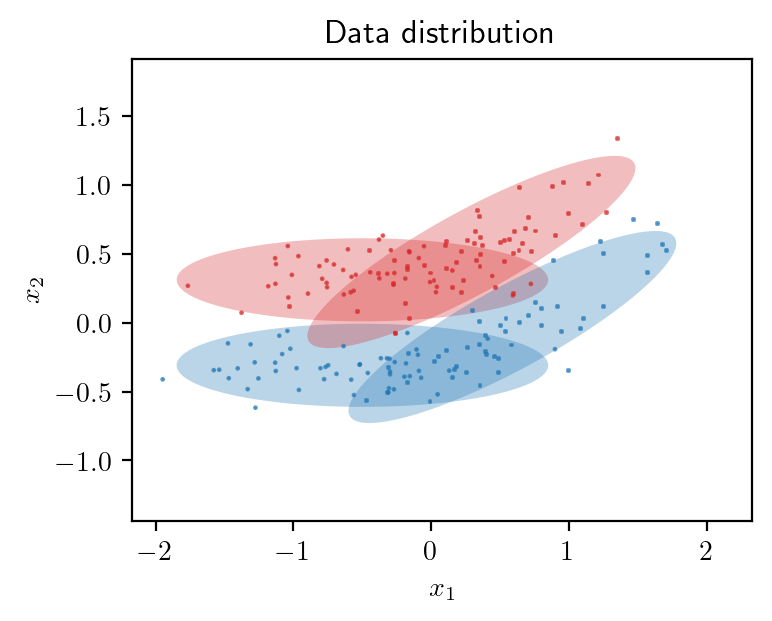

In [5]:
group_offset = np.array([0,0.5])
group_params = dict(
    sigma_y = 0.4,
    sigma_x = 0.02,
    d = 0.31,
)

pop = evoml.Population(groups=[
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2,
        offset=group_offset,
        **group_params,
    ),
    evoml.GaussianPopulationGroup.bivariate_from_angle_offset(
        theta=np.pi/2 + 0.5,
        offset=-group_offset,
        **group_params,
    ),
])

fig,ax=plt.subplots(figsize=(4,3))
evoml.plot_population_distribution(pop,ax=ax,random_state=random_state)


Population game:   0%|          | 0/30 [00:00<?, ?it/s]

<Axes: xlabel='p_B'>

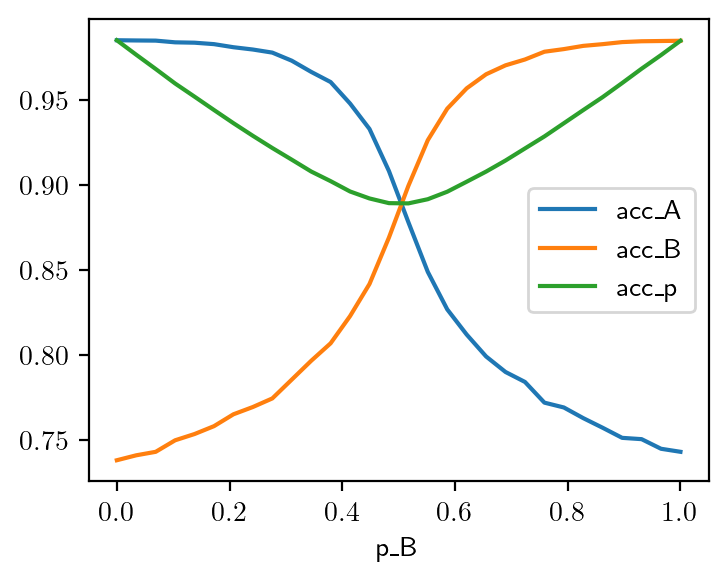

In [6]:
game_df = calculate_population_game_sample(
    pop,
    clf_factory=lambda: evoml.TwoDimensionalEnumerationLinearClassifier(grid_n=200),
    p_vec=p_vec,
    n_train=1000,
    n_test=1000,
    n_reps=500,
    random_state=random_state,
)
game_df.iloc[:,-3:].groupby(level=0).mean().plot.line(figsize=(4,3))

Replicator dynamics:   0%|          | 0/8 [00:00<?, ?it/s]

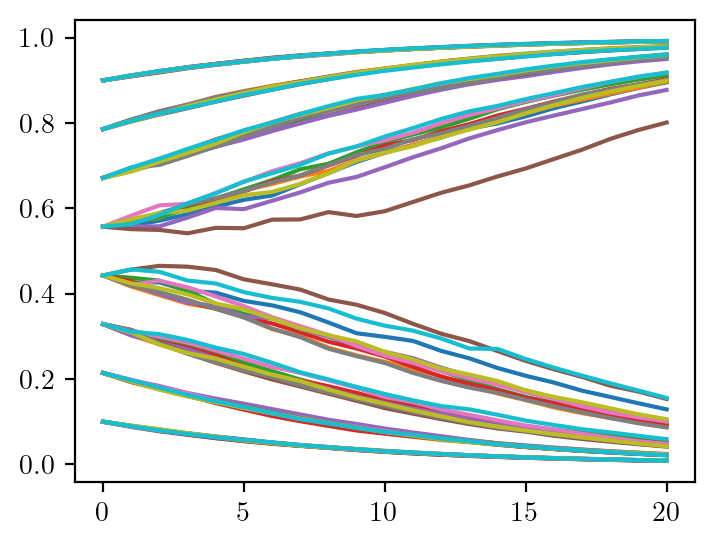

In [7]:
class MarginalAccuracies:
    def __init__(self, pop, clf_factory, n_train, n_test, random_state):
        self.pop = pop
        self.clf_factory = clf_factory
        self.random_state = random_state
        self.n_train = n_train
        self.n_test = n_test

    def __call__(self, p):
        clf = self.clf_factory()
        clf.fit(*self.pop.sample_from_mixture(
            n=self.n_train,
            p=p,
            random_state=self.random_state,
        )[:2])
        return np.array([
            clf.score(*self.pop.sample_from_group(
                n=self.n_test,
                g=g,
                random_state=self.random_state,
            )[:2])
            for g in range(pop.n_groups)
        ])

fitness = MarginalAccuracies(
    pop=pop,
    clf_factory=lambda: evoml.TwoDimensionalEnumerationLinearClassifier(grid_n=200),
    n_train=1000,
    n_test=1000,
    random_state=random_state,
)

p0_vec = np.linspace(0.1,0.9,8)
# p0_vec = np.linspace(0.2,0.8,8)

results = []
for p0 in tqdm(p0_vec, desc='Replicator dynamics'):
    for rep in range(10):
        p = np.array([1-p0,p0])
        out = [p]
        for t in range(20):
            f = fitness(p)+1
            # p += p*(f-p@f)
            # print(p.sum())
            p = (p*f)/(p@f)
            out.append(p)
        results.append(np.vstack(out))
        # ax.plot(np.vstack(out).T[0], alpha=0.15, color=cmap(p[0]*0.6+0.2))

replicator_results = np.stack(results)
fig,ax=plt.subplots(figsize=(4,3))
ax.plot(replicator_results[...,0].T);

Stabilized replicator dynamics:   0%|          | 0/8 [00:00<?, ?it/s]

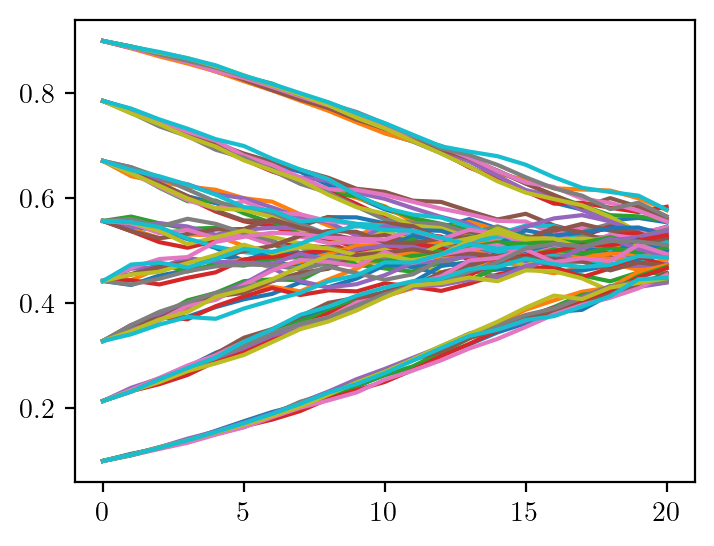

In [8]:
results = []
for p0 in tqdm(p0_vec, desc='Stabilized replicator dynamics'):
    for rep in range(10):
        p = np.array([1-p0,p0])
        out = [p]
        for t in range(20):
            f = fitness(1-p)+1
            # p += p*(f-p@f)
            # print(p.sum())
            p = (p*f)/(p@f)
            out.append(p)
        results.append(np.vstack(out))

stabilized_replicator_results = np.stack(results)
fig,ax=plt.subplots(figsize=(4,3))
ax.plot(stabilized_replicator_results[...,0].T);

Figure saved as ./output/optimal_classifier_prediction_game.pdf


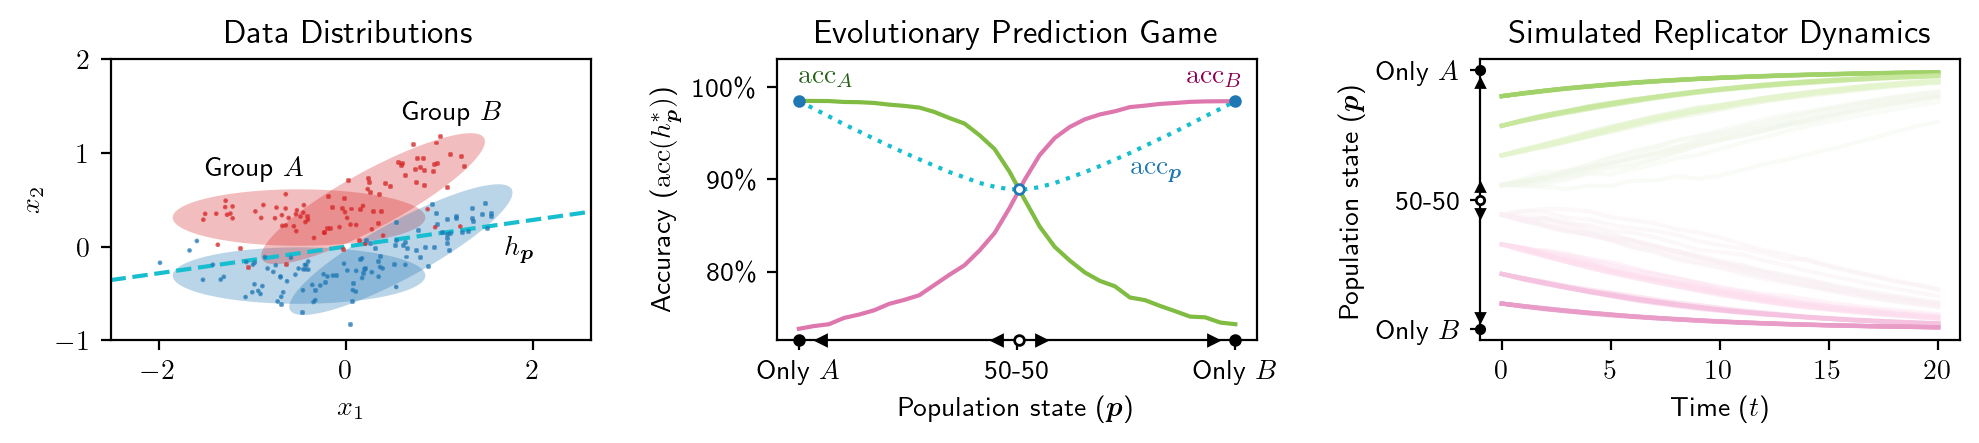

In [9]:
fig, axs = evoml.create_figure(1,3,figsize=(10,2.1))

random_state = np.random.default_rng(12345)

ax = axs[0]
evoml.plot_population_distribution(pop,ax,random_state=random_state)
ax.set_aspect('equal')
ax.set(
    xlim=(-1.9,2.0),
    ylim=(-1,2),
    title='Data Distributions',# ($\\bm{p}=(0.5,0.5)$)',
)
for i,(st,coord) in enumerate([
    ('Group $A$',(-1.5,0.75)),
    ('Group $B$',(0.6,1.35)),
]):
    ax.annotate(
        text=st,
        xy=coord,
        # color=group_colors[i],
    )
ax.annotate(
    text='$h_{\\bm{p}}$',
    xy=(1.7,-0.1),
)

clf = evoml.TwoDimensionalEnumerationLinearClassifier(grid_n=500)
clf.fit(*pop.sample_from_mixture(n=1000,p=[0.5,0.5],random_state=random_state)[:2])
ax.axline(
    xy1=(0,0),
    xy2=np.array([[0,-1],[1,0]])@clf.coef_[0],
    zorder=-1,
    color='tab:cyan',
    linestyle='--',
)

ax = axs[1]
evoml.plot_population_game(
    game_df=game_df.iloc[:,-3:].groupby(level=0).mean(),
    ax=ax,
    equilibria=[
        (0,True),
        (0.505,False),
        (1,True),
    ],
    ax_kwargs=dict(ylim=(None,1.03)),
)
ax.set(
    title='Evolutionary Prediction Game', #  $F_k(\\bm{p})$
    ylabel='Accuracy ($\\mathrm{acc}(h^*_{\\bm{p}})$)',
)

ax.annotate(
    text='$\\mathrm{acc}_A$',
    xy=(0,1.005),
    color=evoml.analysis.group_cmap(1.0),
)
ax.annotate(
    text='$\\mathrm{acc}_B$',
    xy=(0.89,1.005),
    color=evoml.analysis.group_cmap(0.0),
)
ax.annotate(
    text='$\\mathrm{acc}_{\\bm{p}}$',
    xy=(0.76,0.905),
    color='tab:blue',
)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1,decimals=0))

ax = axs[2]
ax.set(
    title='Simulated Replicator Dynamics', #  $F_k(\\bm{p})$
    xlabel='Time ($t$)',
    ylabel=evoml.analysis.composition_label,
    yticks=evoml.analysis.composition_tickpos,
    yticklabels=evoml.analysis.composition_ticklabels,
)

for v in replicator_results:
    ax.plot(v.T[0], alpha=0.4, color=evoml.analysis.group_cmap(v[0,0]*0.6+0.2))

with evoml.analysis.autoscale_turned_off(ax=ax):
    x = ax.get_xlim()[0]       
    for y in [0,0.5,1]:
        ax.plot(
            x,y,
            '.',
            clip_on=False,
            zorder=100,
            color='white' if y==0.5 else 'black',
            markeredgecolor='black',
        )
    for y in [
        0.05,0.45,
        0.55,0.95,
        # 0.25,0.75,
    ]:
        ax.plot(
            x,y,
            marker='v' if y<0.5 else '^',
            clip_on=False,
            zorder=100,
            color='black',
            # color='white' if abs(x-0.5)<0.2 else 'black',
            # markeredgecolor='black',
            markersize=3,
        )


fig.save_and_download('./output/optimal_classifier_prediction_game.pdf')

Figure saved as ./output/optimal_classifier_potential.pdf


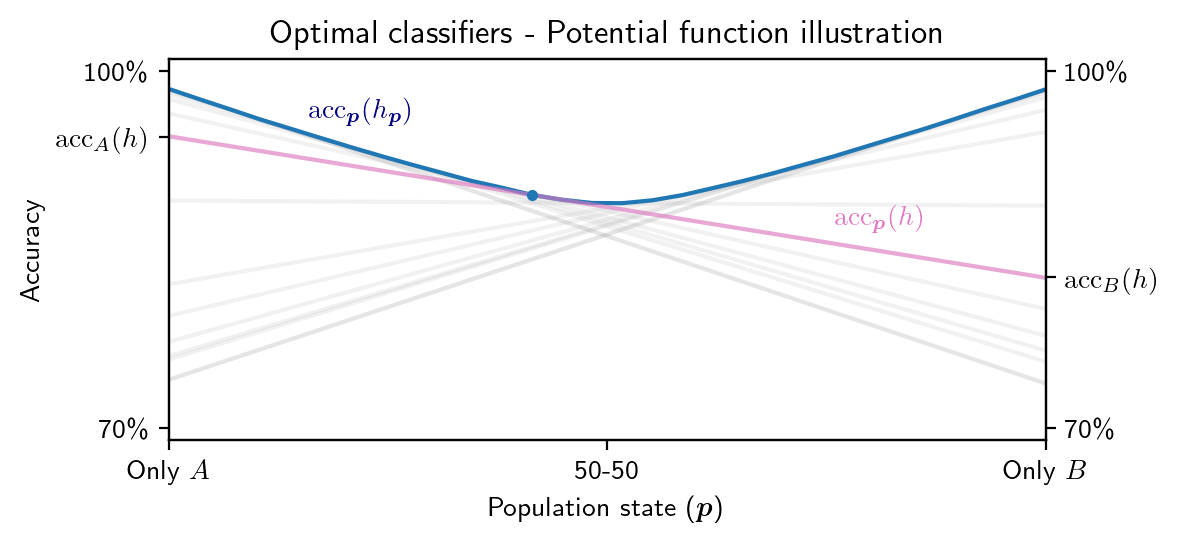

In [10]:
fig,ax=evoml.create_figure(1,1,figsize=(6,2.6))
acc_p = game_df['acc_p'].groupby(level=0).mean()
acc_p.plot.line(ax=ax)
for i in range(0,len(acc_p)-1,2):
    ax.axline(
        xy1=(acc_p.index[i],acc_p.iloc[i]),
        xy2=(acc_p.index[i+1],acc_p.iloc[i+1]),
        zorder=-10,
        color='tab:gray',
        alpha=0.1,
    )
i=12
ax.axline(
    xy1=(acc_p.index[i],acc_p.iloc[i]),
    xy2=(acc_p.index[i+1],acc_p.iloc[i+1]),
    # zorder=-10,
    color='tab:pink',
    alpha=0.6,
)
ax.plot(
    acc_p.index[i],acc_p.iloc[i],'.',color='tab:blue',
)
ax.set(
    xlim=(0,1),
    ylim=(0.69,1.01),
    xlabel=evoml.analysis.composition_label,
    xticks=evoml.analysis.composition_tickpos[::-1],
    xticklabels=evoml.analysis.composition_ticklabels,
    yticks=[0.7,0.945,1.0],
    yticklabels=['70\\%',r'$\mathrm{acc}_A(h)$','100\\%'],
    title='Optimal classifiers - Potential function illustration',
    ylabel=r'Accuracy',
)
ax.annotate(
    text=r'$\mathrm{acc}_{\bm{p}}(h_{\bm{p}})$',
    xy=(0.16,0.96),
    color='navy',
)
ax.annotate(
    text=r'$\mathrm{acc}_{\bm{p}}(h)$',
    xy=(0.76,0.87),
    color='tab:pink',
)


ax2=ax.twinx()
ax2.set(
    ylim=ax.get_ylim(),
    yticks=[0.7,0.827,1.0],
    yticklabels=['70\\%',r'$\mathrm{acc}_B(h)$','100\\%'],
)

evoml.analysis.save_and_download_fig(fig, './output/optimal_classifier_potential.pdf', bbox_inches='tight')